In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
%load_ext autoreload
%autoreload 2

In [2]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import yfinance as yf
import statsmodels.api as sm
import data as dt
import models as md
import backtest as bt
from pathlib import Path
print("OK")

output_dir = Path("../Outputs")

residuals = pd.read_csv(output_dir / "residuals.csv",
                        index_col=0, parse_dates = True)
print(f"Residuals loaded: {residuals.shape}")
print(f"Tickers: {residuals.columns.tolist()}")

OK
Residuals loaded: (901, 7)
Tickers: ['DAL', 'UAL', 'AAL', 'LUV', 'ALK', 'JBLU', 'CPA']


In [3]:
airlines = dt.airlines

In [4]:
univ = ['DAL','UAL','AAL','JBLU','LUV','ALK','CPA','JETS','BZ=F','^VIX','SPY']
px = yf.download(univ, start='2016-01-01', auto_adjust=True,
                   progress=False)['Close']
px = px.rename(columns={'BZ=F':'Brent', '^VIX':'VIX'})
ret = px.pct_change().dropna()
print(f"Downloaded: {px.shape}  |  {px.index[0].date()} → {px.index[-1].date()}")

Downloaded: (2663, 11)  |  2016-01-04 → 2026-07-31


In [5]:
output_dir = Path("../Outputs")
airline_returns = pd.read_csv(output_dir / "airline_returns.csv",index_col=0,parse_dates=True)
macro_returns = pd.read_csv(output_dir / "macro_returns.csv",index_col=0,parse_dates=True)
ticker = 'DAL'
zwin = 45
start = '2022-01-01'
end = '2026-07-29'
residuals = pd.read_csv(output_dir / "residuals.csv", index_col=0, parse_dates=True)
prices = pd.read_csv(output_dir / "airline_returns.csv", index_col=0, parse_dates=True)

print(f"Residuals: {residuals.shape} | {residuals.index[0].date()} → {residuals.index[-1].date()}")
print(f"Prices: {prices.shape} | {prices.index[0].date()} → {prices.index[-1].date()}")
print(f"Available tickers: {residuals.columns.tolist()}")

Residuals: (901, 7) | 2022-12-15 → 2026-07-16
Prices: (2903, 7) | 2015-01-05 → 2026-07-16
Available tickers: ['DAL', 'UAL', 'AAL', 'LUV', 'ALK', 'JBLU', 'CPA']


In [6]:
zscores_full = md.compute_rolling_zscore(residuals, window=zwin)

if ticker not in residuals.columns:
    print(f"ERROR: {ticker} not in residuals. Available: {residuals.columns.tolist()}")
else:

    price_s = prices[ticker].dropna()
    z_s = zscores_full[ticker].dropna()

    common = price_s.index.intersection(z_s.index)
    common = common[(common >= start) & (common <= end)]

    print(f"Common dates in range: {len(common)}")
    if len(common) == 0:
        print(f"No overlap. Price range: {price_s.index[0].date()} → {price_s.index[-1].date()}")
        print(f"Z-score range: {z_s.index[0].date()} → {z_s.index[-1].date()}")
    else:
        price_plot = price_s.loc[common]
        z_plot = z_s.loc[common]
        print(f"Price range: {price_plot.min():.2f} → {price_plot.max():.2f}")
        print(f"Z-score range: {z_plot.min():.3f} → {z_plot.max():.3f}")
        print(f"Signals (z>+2): {(z_plot > 2).sum()} (z<-2): {(z_plot < -2).sum()}")

Common dates in range: 892
Price range: -0.10 → 0.10
Z-score range: -4.101 → 3.919
Signals (z>+2): 27 (z<-2): 27


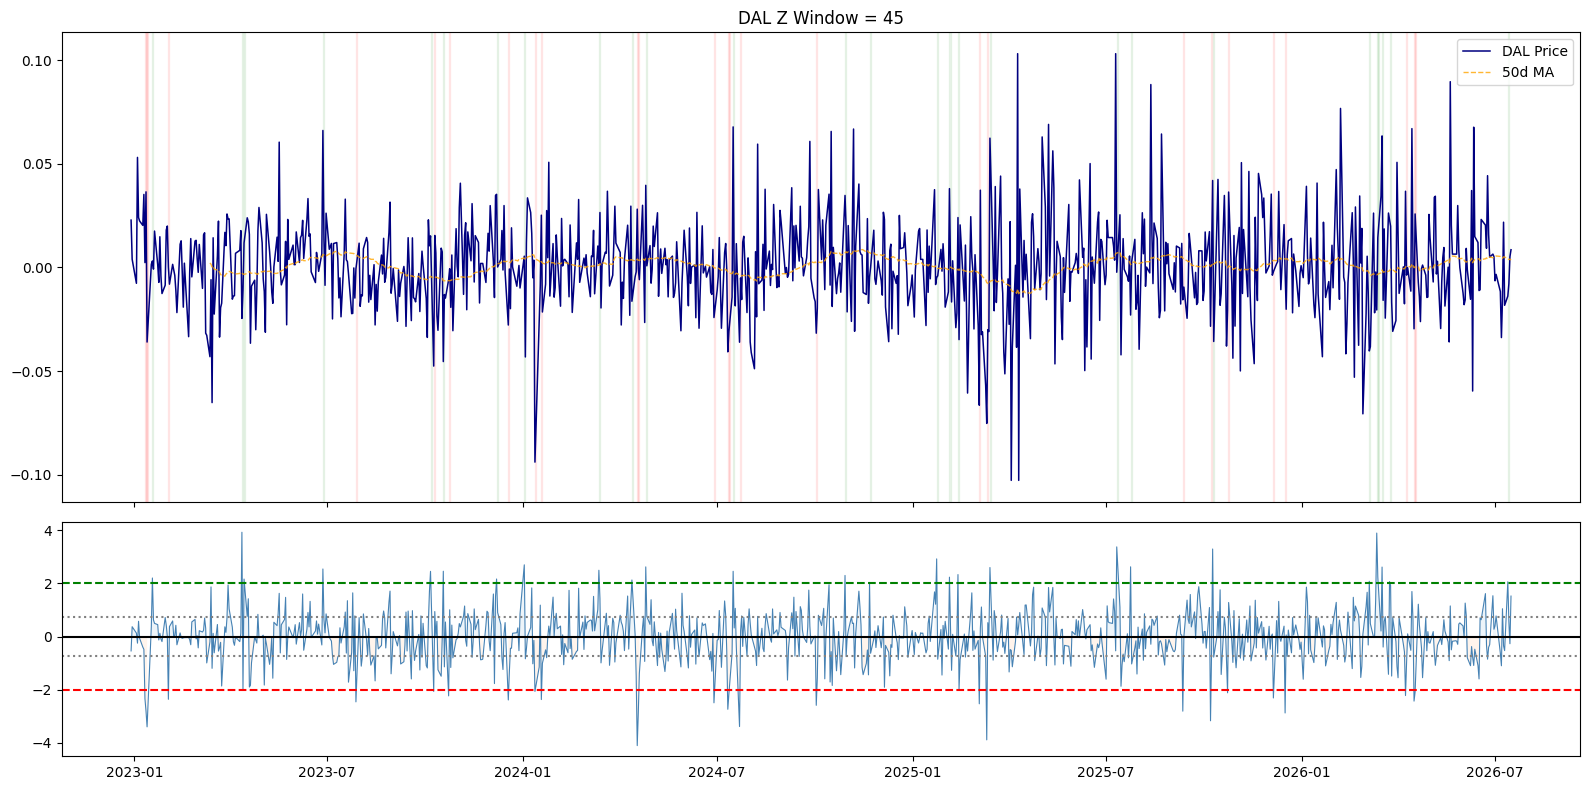

In [7]:
if len(common) > 0:
    price_plot = price_plot.sort_index()
    z_plot = z_plot.sort_index()
    fig, (ax1, ax2) = plt.subplots(2,1,figsize=(16,8),sharex=True,gridspec_kw={"height_ratios":[2,1]})

    ax1.plot(price_plot.index,price_plot.values,color="navy",linewidth=1.1,label=f"{ticker} Price")

    ma50 = price_plot.rolling(50).mean()

    ax1.plot(ma50.index,ma50.values,color="orange",linestyle="--",linewidth=1,alpha=.8,label="50d MA")

    for date, z in z_plot.items():

        if z > 2:
            ax1.axvspan(date,date + pd.Timedelta(days=1),color="green",alpha=.07)

        elif z < -2:
            ax1.axvspan(date,date + pd.Timedelta(days=1),color="red",alpha=.07)

    ax1.set_title(f"{ticker} Z Window = {zwin}")
    ax1.legend()

    ax2.plot(z_plot.index,z_plot.values,color="steelblue",linewidth=.8)

    ax2.axhline(2,color="green",ls="--")
    ax2.axhline(-2,color="red",ls="--")
    ax2.axhline(bt.exit_threshold,color="gray",ls=":")
    ax2.axhline(-bt.exit_threshold,color="gray",ls=":")
    ax2.axhline(0,color="black")

    ax2.fill_between(z_plot.index,z_plot.values,0,where=z_plot>0,alpha=.08)

    ax2.fill_between(z_plot.index,z_plot.values,0,where=z_plot<0,alpha=.08)

    plt.tight_layout()
    plt.show()

In [8]:
output_dir = Path("../Outputs")

prices = pd.read_csv(output_dir/"prices.csv",index_col=0,parse_dates=True)
prices = prices.rename(columns={"BZ=F":"Brent","^VIX":"VIX"})
ret = prices.pct_change().dropna()
px = prices.copy()

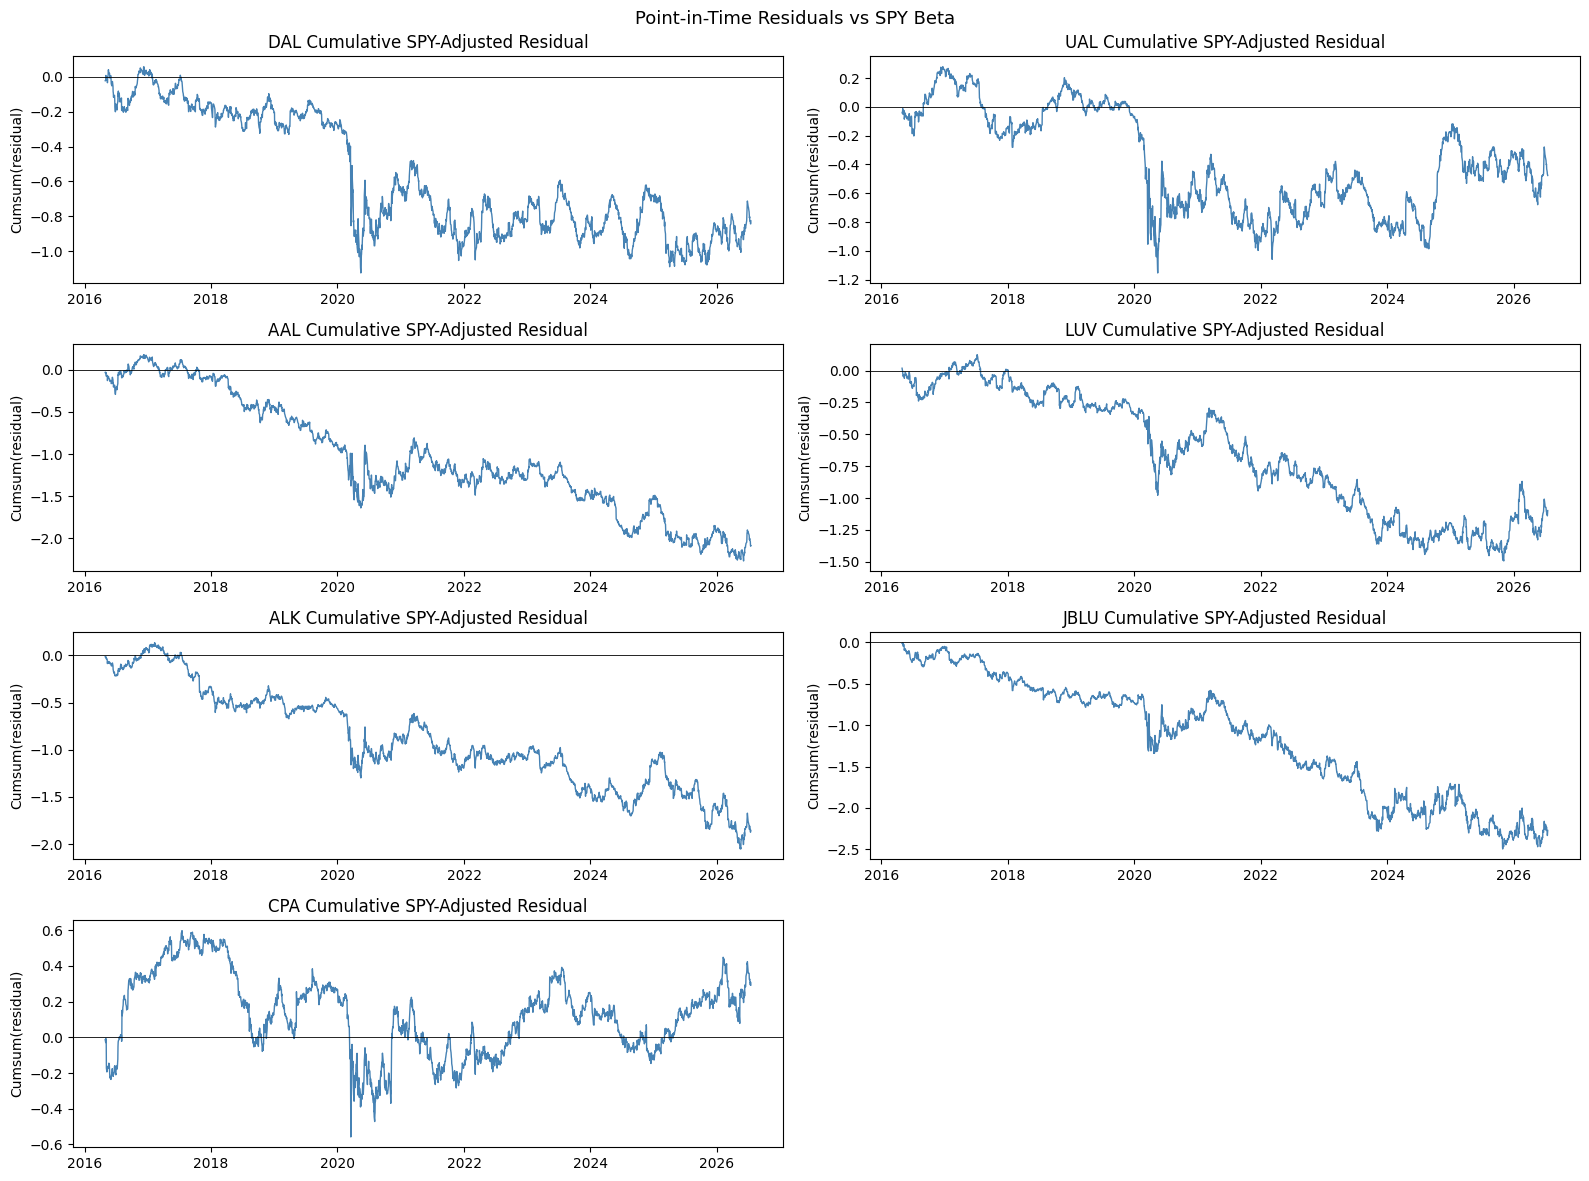

In [9]:
spy_ret = ret['SPY']
corr_r = ret[airlines].rolling(252).corr(spy_ret)
vol_r = ret[airlines].rolling(252).std()
vol_spy = ret['SPY'].rolling(252).std()
beta = corr_r.multiply(vol_r, axis=0).divide(vol_spy, axis=0)
resid = ret[airlines].sub(beta.multiply(spy_ret, axis=0), axis=0)
fig, axes = plt.subplots(4, 2, figsize=(16, 12))
axes = axes.flatten()
for i, t in enumerate(airlines):
    r = resid[t].dropna()
    axes[i].plot(r.cumsum(), color='steelblue', linewidth=1.0)
    axes[i].axhline(0, color='black', linewidth=0.6)
    axes[i].set_title(f"{t} Cumulative SPY-Adjusted Residual")
    axes[i].set_ylabel("Cumsum(residual)")
if len(airlines) < len(axes):
    axes[-1].set_visible(False)
plt.suptitle("Point-in-Time Residuals vs SPY Beta", fontsize=13)
plt.tight_layout()
plt.show()

Information Ratio (residual) vs. Sharpe Ratio (raw):
         IR     SR
DAL  -0.241  0.349
UAL  -0.109  0.351
AAL  -0.454  0.040
LUV  -0.340  0.238
ALK  -0.513  0.140
JBLU -0.465  0.034
CPA   0.073  0.353


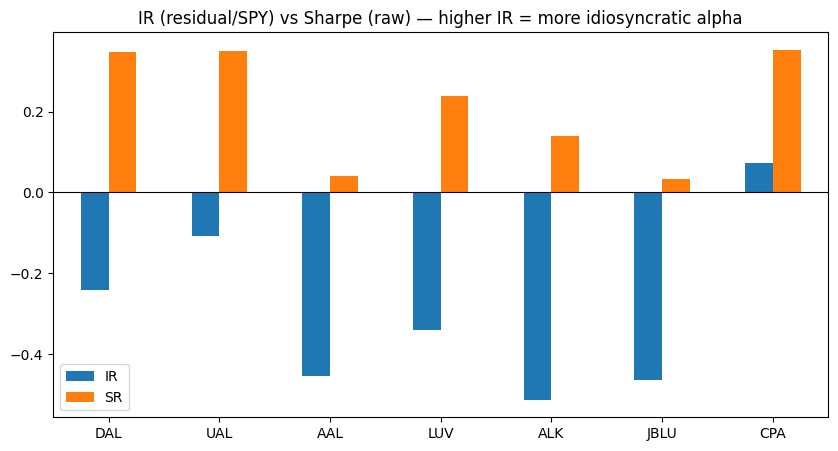

In [10]:
df_stats = pd.DataFrame({
    'IR': (resid[airlines].mean() / resid[airlines].std() * np.sqrt(252)),
    'SR': (ret[airlines].mean() / ret[airlines].std() * np.sqrt(252)),
})
print("Information Ratio (residual) vs. Sharpe Ratio (raw):")
print(df_stats.round(3).to_string())

df_stats.plot(kind='bar', figsize=(10, 5),
    title="IR (residual/SPY) vs Sharpe (raw) — higher IR = more idiosyncratic alpha")
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=0)
plt.show()

Volatility Comparison:
      Raw Vol  Residual Vol
DAL    0.4105        0.3371
UAL    0.5048        0.4309
AAL    0.5149        0.4526
LUV    0.3704        0.3183
ALK    0.4259        0.3559
JBLU   0.5313        0.4815
CPA    0.4570        0.3927


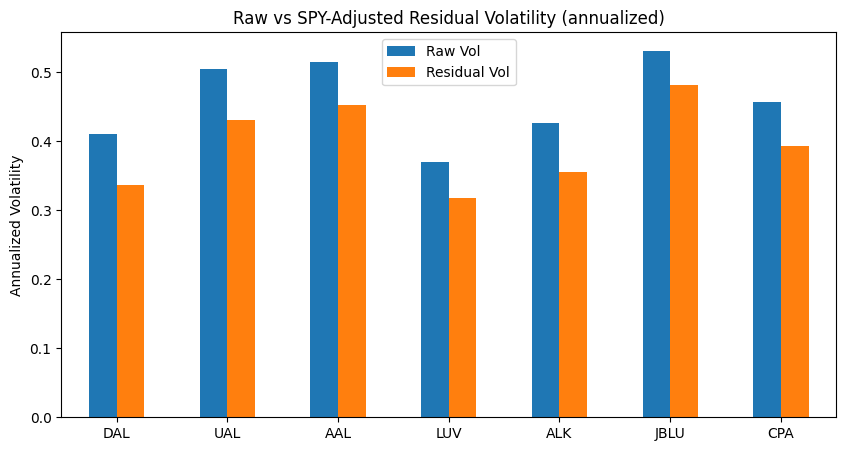

In [11]:
vol_compare = pd.DataFrame({
    'Raw Vol': ret[airlines].std() * np.sqrt(252),
    'Residual Vol': resid[airlines].std() * np.sqrt(252),
})
print("Volatility Comparison:")
print(vol_compare.round(4))

vol_compare.plot(kind='bar', figsize=(10,5),
    title="Raw vs SPY-Adjusted Residual Volatility (annualized)")
plt.xticks(rotation=0)
plt.ylabel("Annualized Volatility")
plt.show()

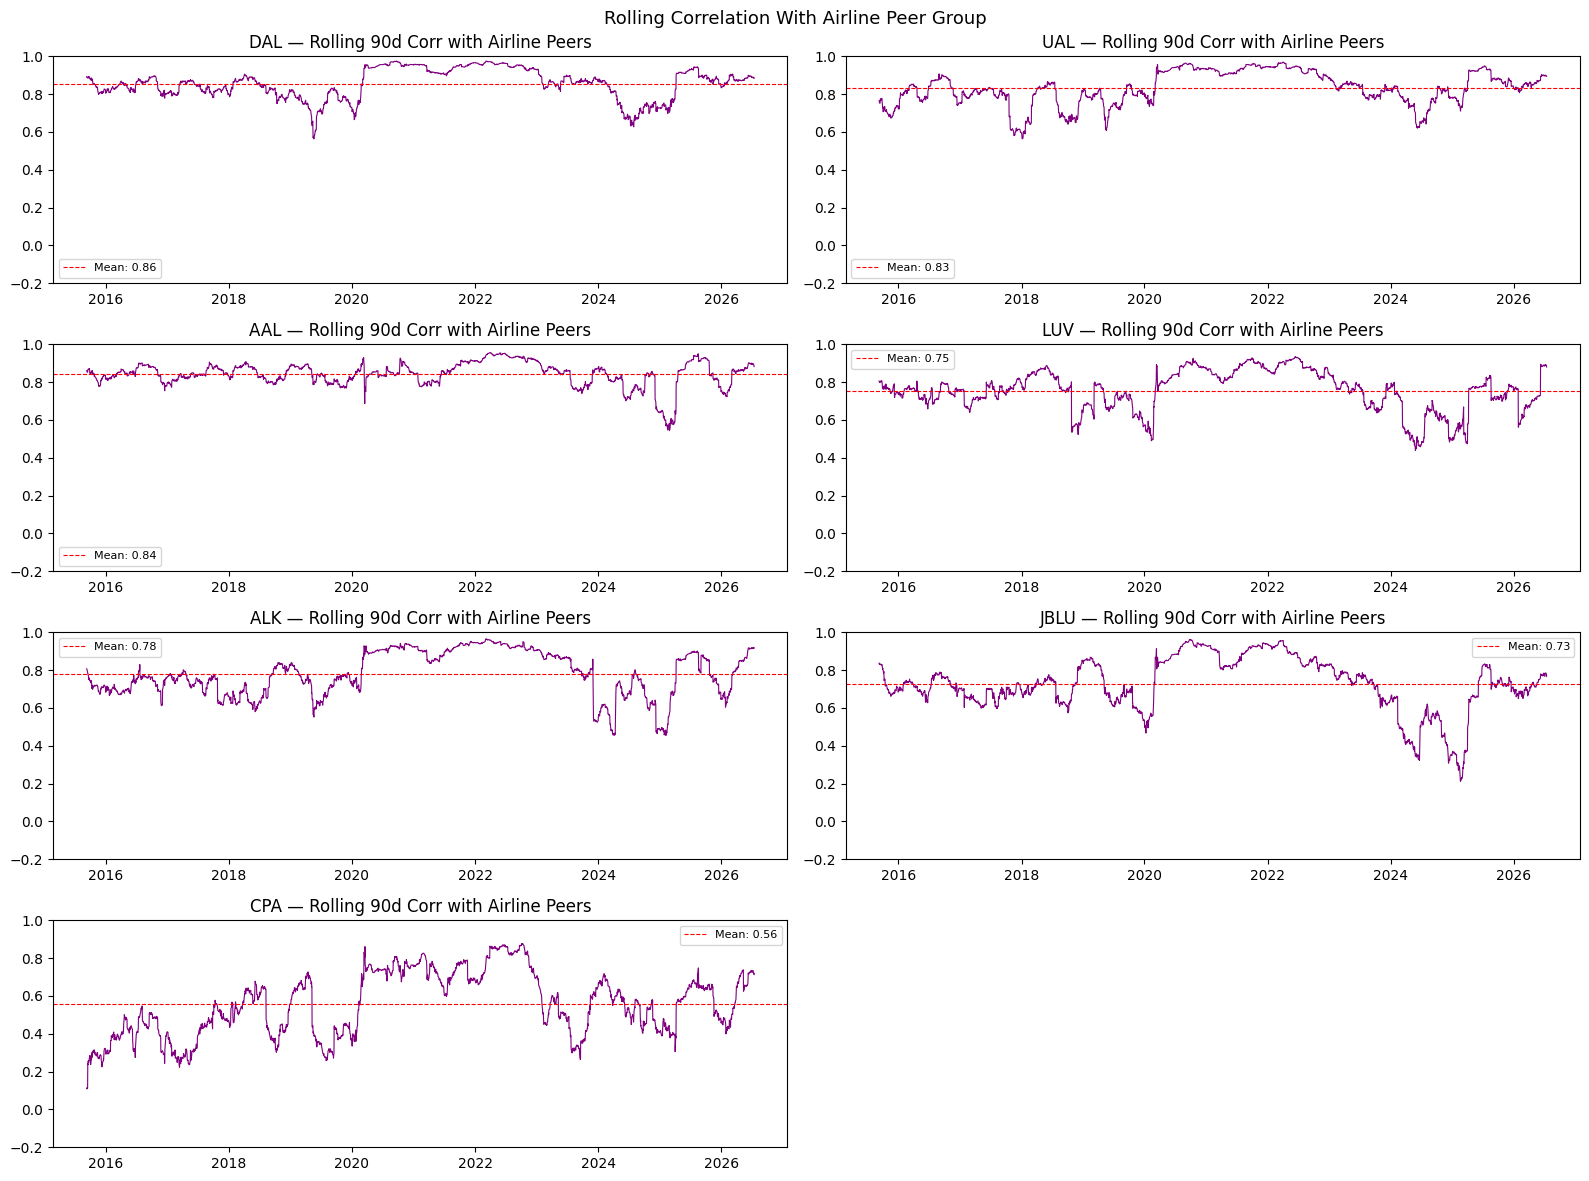

In [12]:
fig, axes = plt.subplots(4, 2, figsize=(16, 12))
axes = axes.flatten()
for i, t in enumerate(airlines):
    others = [x for x in airlines if x != t]
    rolling_corr = ret[t].rolling(90).corr(ret[others].mean(axis=1))
    axes[i].plot(rolling_corr, color='purple', linewidth=0.8)
    axes[i].axhline(rolling_corr.mean(), color='red', linestyle='--',
                    linewidth=0.8, label=f"Mean: {rolling_corr.mean():.2f}")
    axes[i].set_title(f"{t} — Rolling 90d Corr with Airline Peers")
    axes[i].set_ylim(-0.2, 1.0)
    axes[i].legend(fontsize=8)
if len(airlines) < len(axes):
    axes[-1].set_visible(False)
plt.suptitle("Rolling Correlation With Airline Peer Group", fontsize=13)
plt.tight_layout()
plt.show()

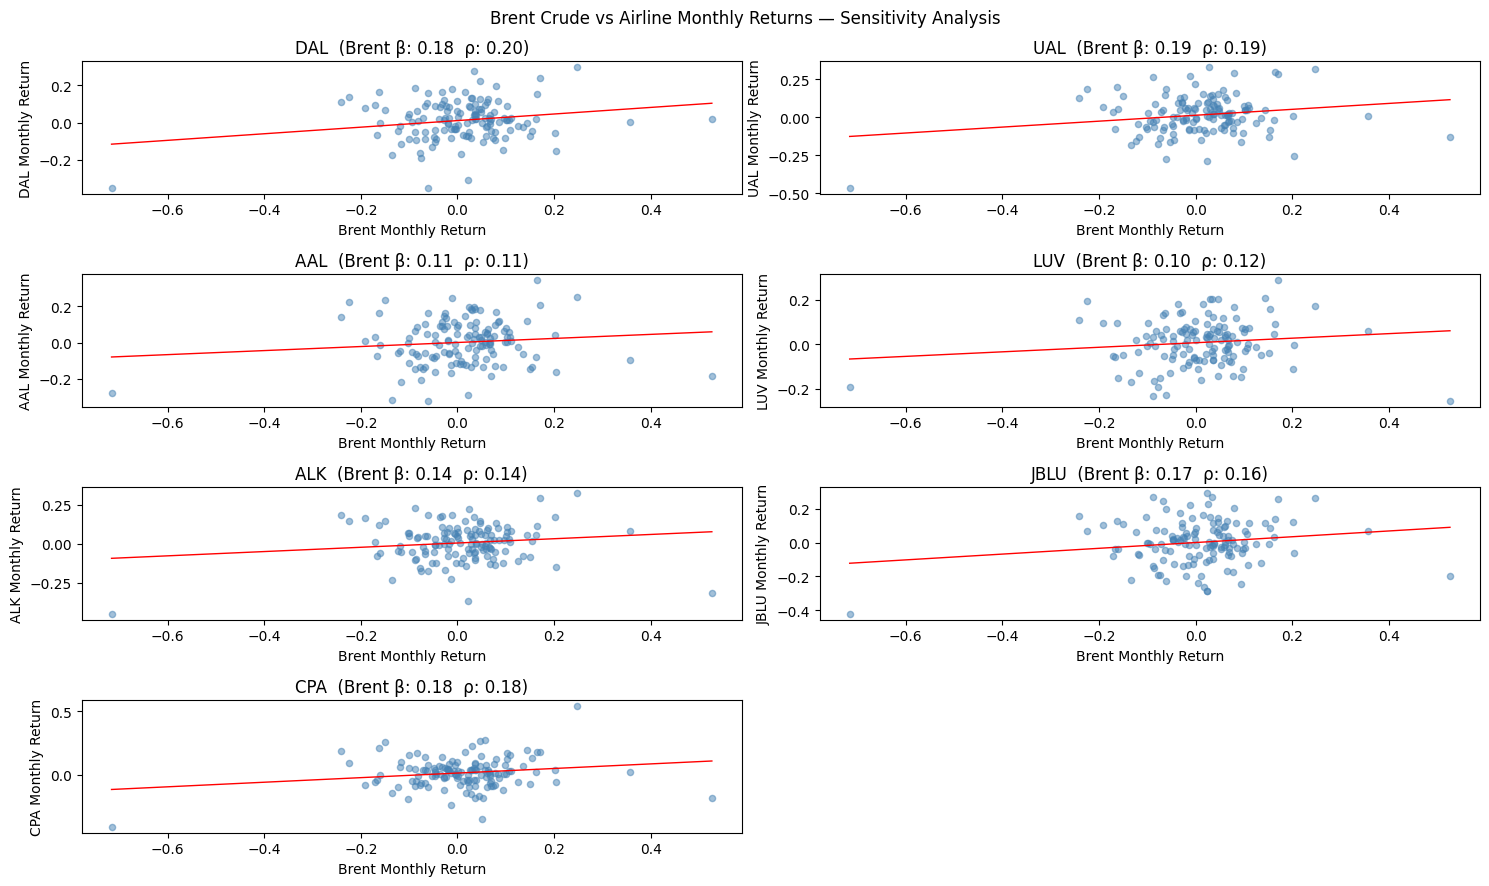

In [13]:
fig, axes = plt.subplots(4, 2, figsize=(15, 9))
axes = axes.flatten()
brent_monthly = ret['Brent'].resample('ME').sum()
for i, t in enumerate(airlines):
    air_monthly = ret[t].resample('ME').sum()
    common = brent_monthly.index.intersection(air_monthly.index)
    x = brent_monthly.loc[common]
    y = air_monthly.loc[common]
    axes[i].scatter(x, y, alpha=0.5, s=20, color='steelblue')
    m, b_, *_ = np.polyfit(x, y, 1)
    xl = np.linspace(x.min(), x.max(), 100)
    axes[i].plot(xl, m*xl + b_, color='red', linewidth=1.0)
    corr = x.corr(y)
    axes[i].set_title(f"{t}  (Brent β: {m:.2f}  ρ: {corr:.2f})")
    axes[i].set_xlabel("Brent Monthly Return")
    axes[i].set_ylabel(f"{t} Monthly Return")
if len(airlines) < len(axes):
    axes[-1].set_visible(False)
plt.suptitle("Brent Crude vs Airline Monthly Returns — Sensitivity Analysis",
             fontsize=12)
plt.tight_layout()
plt.show()

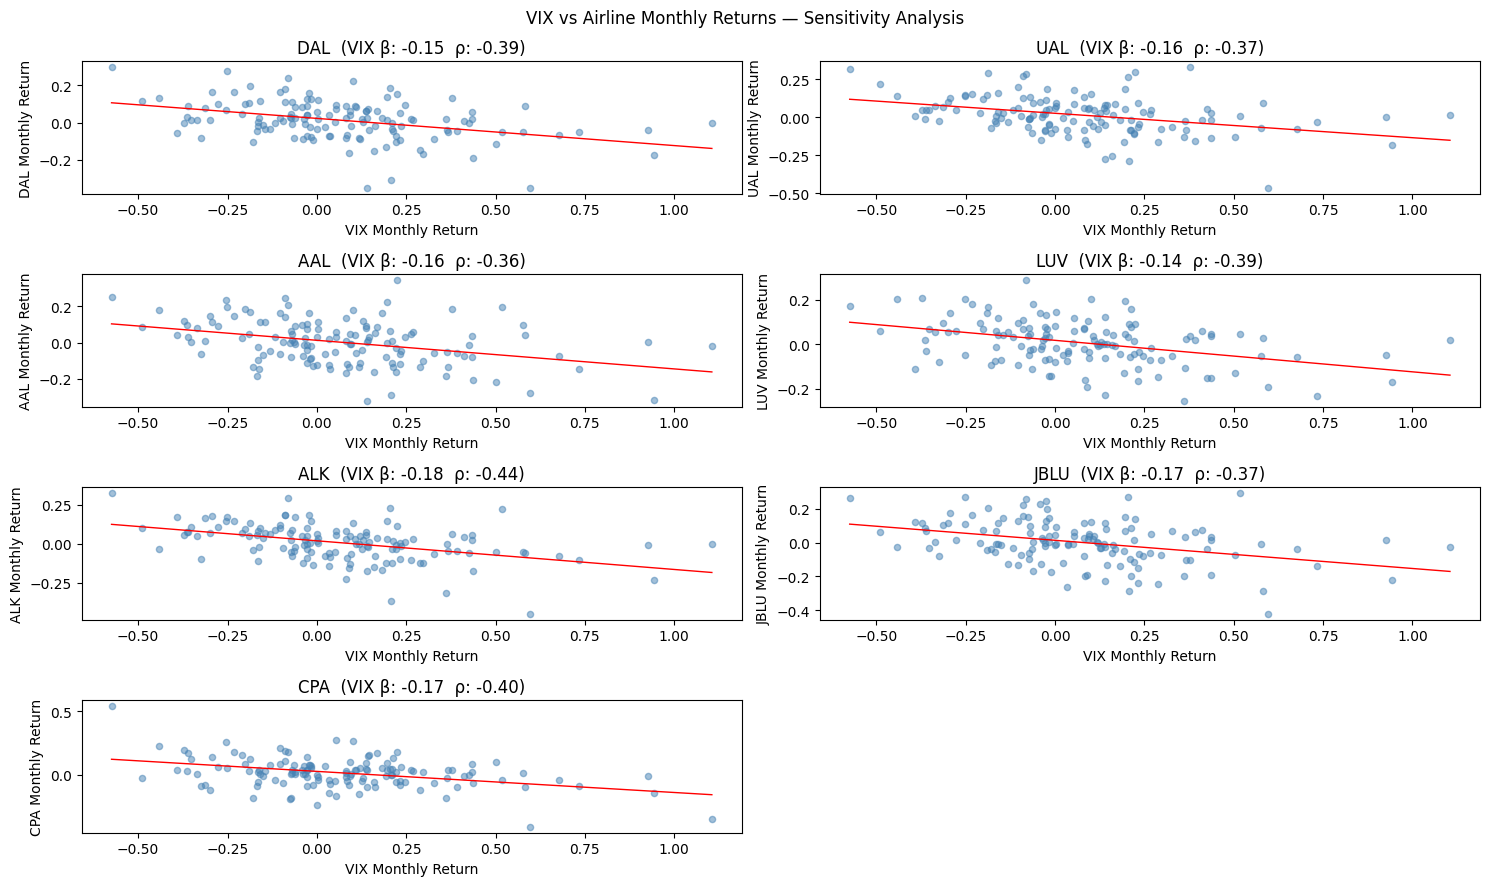

In [14]:
fig, axes = plt.subplots(4, 2, figsize=(15, 9))
axes = axes.flatten()
vix_monthly = ret['VIX'].resample('ME').sum()
for i, t in enumerate(airlines):
    air_monthly = ret[t].resample('ME').sum()
    common = vix_monthly.index.intersection(air_monthly.index)
    x = vix_monthly.loc[common]
    y = air_monthly.loc[common]
    axes[i].scatter(x, y, alpha=0.5, s=20, color='steelblue')
    m, b_, *_ = np.polyfit(x, y, 1)
    xl = np.linspace(x.min(), x.max(), 100)
    axes[i].plot(xl, m*xl + b_, color='red', linewidth=1.0)
    corr = x.corr(y)
    axes[i].set_title(f"{t}  (VIX β: {m:.2f}  ρ: {corr:.2f})")
    axes[i].set_xlabel("VIX Monthly Return")
    axes[i].set_ylabel(f"{t} Monthly Return")
if len(airlines) < len(axes):
    axes[-1].set_visible(False)
plt.suptitle("VIX vs Airline Monthly Returns — Sensitivity Analysis",
             fontsize=12)
plt.tight_layout()
plt.show()

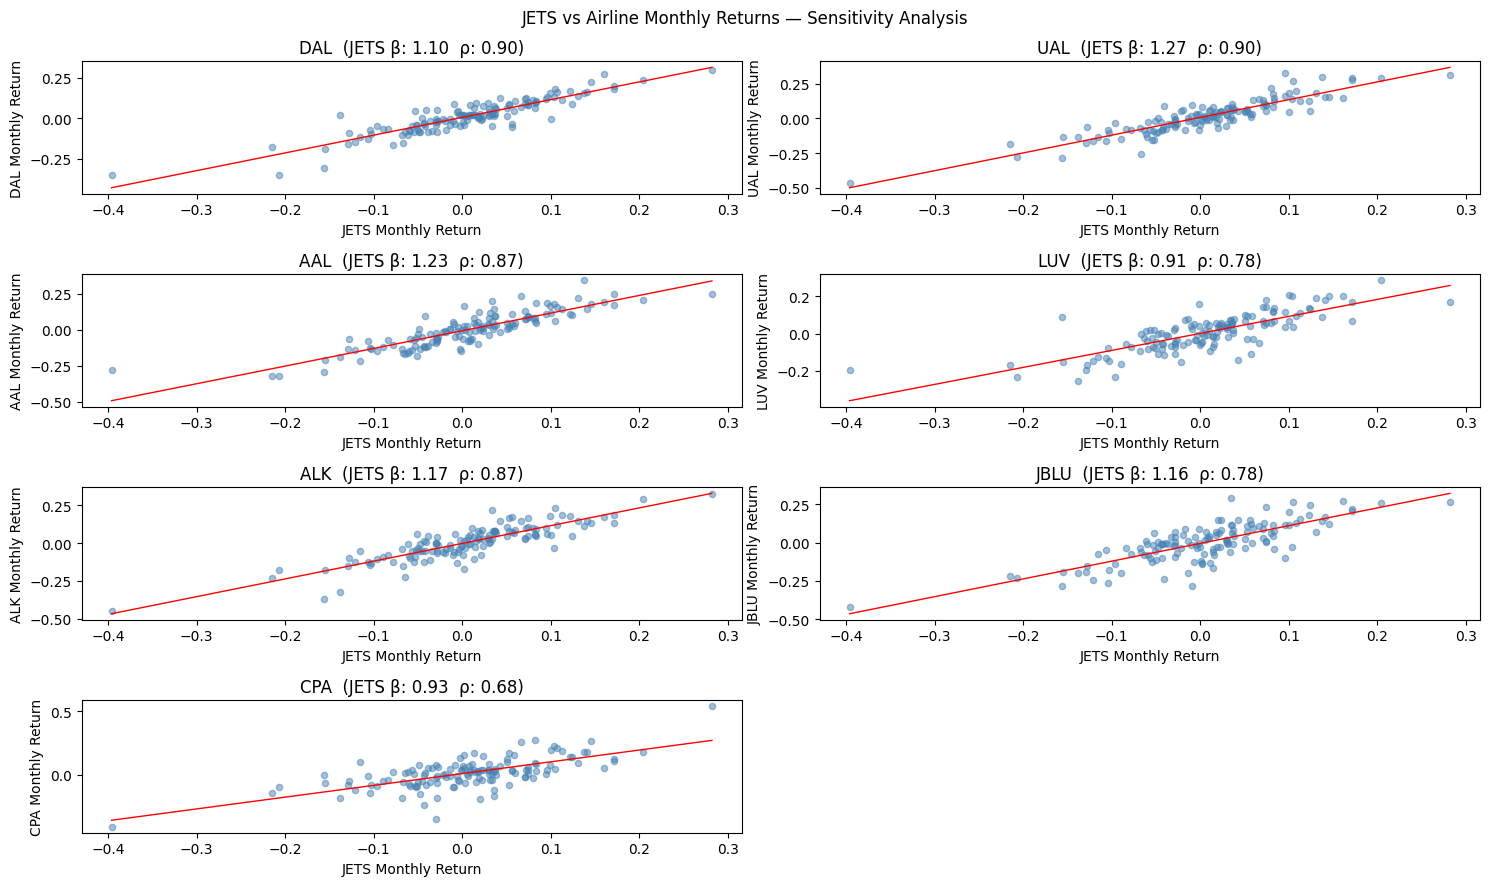

In [15]:
fig, axes = plt.subplots(4, 2, figsize=(15, 9))
axes = axes.flatten()
jets_monthly = ret['JETS'].resample('ME').sum()
for i, t in enumerate(airlines):
    air_monthly = ret[t].resample('ME').sum()
    common = jets_monthly.index.intersection(air_monthly.index)
    x = jets_monthly.loc[common]
    y = air_monthly.loc[common]
    axes[i].scatter(x, y, alpha=0.5, s=20, color='steelblue')
    m, b_, *_ = np.polyfit(x, y, 1)
    xl = np.linspace(x.min(), x.max(), 100)
    axes[i].plot(xl, m*xl + b_, color='red', linewidth=1.0)
    corr = x.corr(y)
    axes[i].set_title(f"{t}  (JETS β: {m:.2f}  ρ: {corr:.2f})")
    axes[i].set_xlabel("JETS Monthly Return")
    axes[i].set_ylabel(f"{t} Monthly Return")
if len(airlines) < len(axes):
    axes[-1].set_visible(False)
plt.suptitle("JETS vs Airline Monthly Returns — Sensitivity Analysis",
             fontsize=12)
plt.tight_layout()
plt.show()

,Window,Sharpe,Annual Return,Turnover
0,20,-0.269,-0.0498,39.641
1,30,-0.018,-0.0034,35.651
2,45,-0.039,-0.0070,34.159
3,60,-0.230,-0.0404,34.835
4,75,-0.426,-0.0716,33.428
5,90,-0.038,-0.0062,32.313


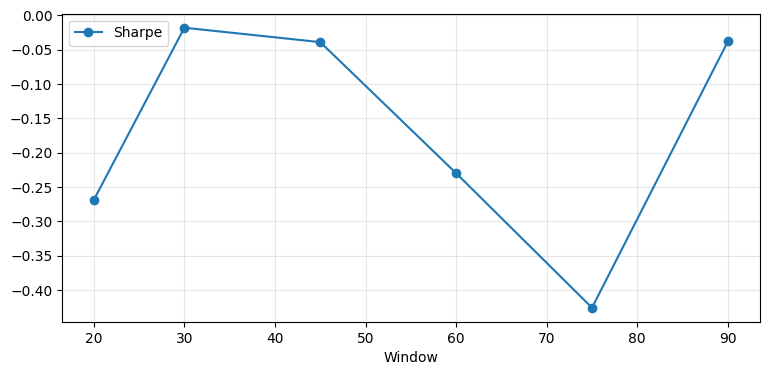

In [16]:
windows = [20,30,45,60,75,90]
summary = []
for w in windows:
    z = md.compute_rolling_zscore(residuals, window=w)
    signals = bt.generate_signals(z,top_n=bt.top_n,exit_ = bt.exit_threshold, min_hold = bt.min_hold_days, momentum = False)
    positions = bt.construct_portfolio(signals, zscores = z, residuals = residuals)
    net, trades = bt.compute_portfolio_returns(positions, airline_returns)
    perf = bt.compute_performance(net, trades, macro_returns)

    summary.append({"Window":w,"Sharpe":perf["sharpe_ratio"],"Annual Return":perf["annualized_returns"],"Turnover":perf["ann_turnover"]})

summary = pd.DataFrame(summary)

display(summary)

summary.plot(x = "Window", y = "Sharpe", marker="o", figsize=(9,4))
plt.grid(alpha=.3)
plt.show()